## Process Data

In [1]:
import pandas as pd

aol_df = pd.read_csv("user-ct-test-collection-02.txt", delimiter="\t")
aol_df.head()

,AnonID,Query,QueryTime,ItemRank,ClickURL
0,479,family guy,2006-03-01 16:01:20,NaN,NaN
1,479,also sprach zarathustra,2006-03-02 14:48:55,NaN,NaN
2,479,family guy movie references,2006-03-03 22:37:46,1.0,http://www.familyguyfiles.com
3,479,top grossing movies of all time,2006-03-03 22:42:42,1.0,http://movieweb.com
4,479,top grossing movies of all time,2006-03-03 22:42:42,2.0,http://www.imdb.com


In [2]:
aol_sorted = aol_df.sort_values(by="QueryTime")
aol_sorted.head()

,AnonID,Query,QueryTime,ItemRank,ClickURL
328959,811283,new jersey inside water parks,2006-03-01 00:01:16,1.0,http://themeparks.about.com
432072,1082283,cancionero,2006-03-01 00:01:26,4.0,http://www.cancionerolatino.com.ar
432073,1082283,cancionero,2006-03-01 00:01:26,4.0,http://www.cancionerolatino.com.ar
432074,1082283,cancionero,2006-03-01 00:01:26,6.0,http://www.nuevosvalores.com
432075,1082283,cancionero,2006-03-01 00:01:26,2.0,http://www.cancionero.com.ar


In [3]:
aol_sorted.tail()

,AnonID,Query,QueryTime,ItemRank,ClickURL
2710854,10257280,syntace stem,2006-05-31 23:59:45,2.0,http://www.trisports.com
986729,2462060,patio doors,2006-05-31 23:59:49,NaN,NaN
2864669,11533607,south africa's political structure,2006-05-31 23:59:51,1.0,http://en.wikipedia.org
2864670,11533607,south africa's political structure,2006-05-31 23:59:51,4.0,http://www.bbc.co.uk
439305,1103248,-,2006-05-31 23:59:56,NaN,NaN


In [4]:
aol_sorted.to_clipboard(columns=['AnonID'], index=False)

## Parallel SS/SSA

In [44]:
def estimate_norm(timestep, order, r1, r2, q):
    '''
    Description:
        Helper function to estimate norm at timestep based on its histogram
    Input:
        hist: histogram to use for norms
        timestep: timestep for which to estimte order norm
        order: order of norm
        r1: number of values to take median of
        r2: number of values to take mean of
        q: threshold of ssa algorithm
    Returns:
        Order norm at timestep
    '''
    t = hist_ssa[timestep] # keeps track of samples
    r1_norms = []
    for i in range(r1):
        r2_norms = []
        t_i = t[i] # sample for current iteration
        for j in range(r2):
            curr_t = t_i[j]
            moment = np.sum(np.power(list(curr_t.values()), order))
            r2_norms.append(
                    np.power((1/q * moment), 1/order)
                )
        r1_norms.append(np.mean(r2_norms))
    rest_est = np.median(r1_norms)
    temp_arr = np.concatenate((hist_hh_sums[timestep], [rest_est]))
    return np.linalg.norm(temp_arr, order)

In [45]:
def prune_threads_ssa(order, r1, r2, q):
    '''
    Description:
        Removes adjacent threads that are within a threshold of 2
    Inputs:
        order: order of norm
        r1: number of values to take median of
        r2: number of values to take mean of
        q: threshold for ssa algorithm
    '''
    i = 0 # index variable
    while (i < len(threads_vec_ssa)):
        # boundary check
        if (i >= len(threads_vec_ssa) - 2):
            return
        t_i = threads_vec_ssa[i] # thread identity
        ssa_ti = estimate_norm(t_i, order, r1, r2, q) # ssa estimate for thread

        t_i2 = threads_vec_ssa[i+2] # adjcaent thread
        ssa_ti2 = estimate_norm(t_i2, order, r1, r2, q) # ssa estimate for adjancent thread
        
        # check distance, prune hist, threads
        denom = min(ssa_ti, ssa_ti2)
        if (denom != 0 and (max(ssa_ti, ssa_ti2)/denom <= 2)):
            # remove the thread in between
            t_i1 = threads_vec_ssa[i+1]
            threads_vec_ssa.pop(i+1)
            hist_ssa.pop(t_i1)
            hist_ss.pop(t_i1)
            hist_hh_sums.pop(t_i1)
            i -= 1
        i += 1

In [46]:
def spawn_threads_ssa(timestep, order, l, r1, r2, q):
    '''
    Description:
        Helper function to spawn threads for ssa
    Inputs:
        timestep: timestep identifier to spawn threads for ssa
        order: order of norm
        l: number of heavy hitters
        r1: number of values to take median of
        r2: number of values to take mean of
        q: threshold for ssa algorithm
    '''
    if (len(threads_vec_ssa) == num_threads_max):
        prune_threads_ssa(order, r1, r2, q)
    if (len(threads_vec_ssa) < num_threads_max):
        threads_vec_ssa.append(timestep)
        hist_ssa[timestep] = [[{} for _ in range(r2)] for _ in range(r1)]
        hist_ss[timestep] = [[{} for _ in range(r2)] for _ in range(r1)]
        hist_hh_sums[timestep] = np.zeros(l)

In [47]:
def selective_subsampling(s_i, r1, r2, q):
    '''
    Description:
        Helper method to run ss in parallel with ssa
    Inputs:
        s_i: the current stream value
        r1: number of values to take median of
        r2: number of values to take mean of
        
    '''
    for thread in threads_vec_ssa:
        t = hist_ss[thread]
        for i in range(r1):
            t_i = t[i]
            for j in range(r2):
                curr_t = t_i[j]
                prob = seeded_input_random((i+1)*(j+1) + s_i, s_i)
                if (prob < q):
                    curr_t.setdefault(s_i, 0)
                    curr_t[s_i] += 1

In [48]:
import numpy as np
from utils import seeded_input_random
import csv

def selective_subsampling_augmented(heavy, filepath, order, limit, r1, r2, q, q_ss):
    '''
    Description:
        Uses augmented selective subsampling algorithm to estimate order norm of frequencies
    Inputs:
        heavy: list of heavy hitters IP addresses
        filepath: file to run algorithm on
        order: order of norm
        limit: number of addresses to process
        r1: number of values to take median of
        r2: number of values to take mean of
        q: threshold for ssa algorithm
        q_ss: threshold for ss algorithm
    Outputs:
        returns estimated order norm of frequency vector
    '''
    
    with open(filepath) as csvfile:
        stream = csv.reader(csvfile, delimiter=",")
        stream.__next__() # get rid of the header
        time = 1
        for row in stream:
            if (stream.line_num == limit):
                break
            try:
                s_i = int(row[0])
            except:
                # ip address is not valid IPv4 or IPv6 address
                continue
            vals.append(s_i)
            # run augmented algorithm
            spawn_threads_ssa(time, order, len(heavy), r1, r2, q)
            try:
                index = heavy.index(s_i)
                # s_i is a heavy hitter
                for thread in threads_vec_ssa:
                    t = hist_hh_sums[thread]
                    t[index] += 1
            except ValueError:
                # s_i is not a heavy hitter
                for thread in threads_vec_ssa:
                    t = hist_ssa[thread]
                    for i in range(r1):
                        t_i = t[i]
                        for j in range(r2):
                            curr_t = t_i[j]
                            prob = seeded_input_random((i+1)*(j+1) + s_i, s_i)
                            if (prob < q):
                                curr_t.setdefault(s_i, 0)
                                curr_t[s_i] += 1
            finally:
                # run ss in parallel
                selective_subsampling(s_i, r1, r2, q_ss)
                time += 1

## AOL Dataset Test

In [38]:
# from cs
hh = [2708,
 14530,
 19913,
 30063,
 31910,
 59766,
 81902,
 94748,
 98594,
 112549,
 136429,
 231764,
 234490,
 235802,
 242755,
 268550,
 350228,
 386598,
 468720,
 490033,
 495960,
 505568,
 528269,
 544822,
 582943,
 595064,
 607249,
 638885,
 641882,
 644634,
 657233,
 666760,
 671587,
 672897,
 749116,
 784926,
 799336,
 809164,
 839825,
 870559,
 893990,
 907640,
 949884,
 1041520,
 1090292,
 1105372,
 1108764,
 1145810,
 1178078,
 1199246,
 1199906,
 1235663,
 1251005,
 1258520,
 1311602,
 1314128,
 1316538,
 1342978,
 1344179,
 1360709,
 1395579,
 1436599,
 1460885,
 1484685,
 1496895,
 1536200,
 1551168,
 1565388,
 1566364,
 1664362,
 1673928,
 1700699,
 1704474,
 1717963,
 1803937,
 1826994,
 1845373,
 1884580,
 1919698,
 1944301,
 1945467,
 1955947,
 1998576,
 2008602,
 2053307,
 2061594,
 2097493,
 2120617,
 2124018,
 2162282,
 2175385,
 2186066,
 2202596,
 2228313,
 2248354,
 2256996,
 2262369,
 2265240,
 2280767,
 2332095,
 2373521,
 2382113,
 2399416,
 2426641,
 2503321,
 2523281,
 2532935,
 2541128,
 2559430,
 2590883,
 2665695,
 2682392,
 2699054,
 2700537,
 2730599,
 2747414,
 2749521,
 2755954,
 2779372,
 2875718,
 2932694,
 2933929,
 2951243,
 2963792,
 2994485,
 3019805,
 3033935,
 3034929,
 3131451,
 3177006,
 3180271,
 3241766,
 3247870,
 3318459,
 3390279,
 3394675,
 3400024,
 3414878,
 3439662,
 3501213,
 3507274,
 3510572,
 3512782,
 3525209,
 3547648,
 3552531,
 3556698,
 3568883,
 3610110,
 3634829,
 3638979,
 3657428,
 3657840,
 3751563,
 3782464,
 3811939,
 3819506,
 3855871,
 3901843,
 4051910,
 4276751,
 4309593,
 4314807,
 4360867,
 4372087,
 4374147,
 4408990,
 4533510,
 4538306,
 4555485,
 4615477,
 4620308,
 4667729,
 4668440,
 4692726,
 4724591,
 4736350,
 4754354,
 4823649,
 4827349,
 4843753,
 4903984,
 4936979,
 4998669,
 5109143,
 5141688,
 5144903,
 5153350,
 5163449,
 5166258,
 5231549,
 5242136,
 5289919,
 5291094,
 5329922,
 5339829,
 5395927,
 5488213,
 5526272,
 5528656,
 5551497,
 5688329,
 5874984,
 5913637,
 6352620
 ]

In [ ]:
# set up shared variables
hist_ssa = {} # maps timestep to ssa value
hist_ss = {} # maps timestep to ss value
hist_hh_sums = {} # maps timestep to hh sum value
threads_vec_ssa = [] # stores thread identities
num_threads_max = 20 # hyperparam for max counters
vals = []
r1 = 3
r2 = 5
order = 3
q = 1/75
q_ss = 1/75
filepath = "aol-processed.csv"
m = int(2e6)

selective_subsampling_augmented(heavy=hh, filepath=filepath, order=order, limit=m, r1=r1, r2=r2, q=q, q_ss=q_ss)


### Visualize Results

In [50]:
def norm_helper(time, order, r1, r2, q):
    '''
        Description:
            Helper function to calculate order norm for ss
        Inputs:
            time: timestep for calculation
            order: order of norm
            r1: number of values to take median of
            r2: number of values to take mean of
            q: threshold for ss algorithm
        Outputs:
            order norm
    '''
    t = hist_ss[time] # keeps track of samples
    r1_norms = []
    for i in range(r1):
        r2_norms = []
        t_i = t[i] # sample for current iteration
        for j in range(r2):
            curr_t = t_i[j]
            moment = np.sum(np.power(list(curr_t.values()), order))
            r2_norms.append(
                    np.power((1/q * moment), 1/order)
                )
        r1_norms.append(np.mean(r2_norms))
    
    return np.median(r1_norms)

In [51]:
def calculate_estimates():
    '''
    Description:
        Calculates estimates for ssa/ss and computes ground truth
    Inputs:
        None
    Outputs:
        timesteps: unpruned timesteps
        est_ssa: ssa estimates corresponding to timesteps
        est_ss: ss estimates corresponding to timesteps
        gt: ground truth vaues corresponding to timesteps
    '''
    timesteps = []
    est_ssa = []
    est_ss = []
    gt = []
    for time in hist_ssa.keys():
        timesteps.append(time)
        est_ssa.append(estimate_norm(time, order, r1, r2, q))
        est_ss.append(norm_helper(time, order, r1, r2, q_ss))    
        _, temp_freq = np.unique(vals[time:], return_counts=True)
        gt.append(np.linalg.norm(temp_freq, order))
    return timesteps, est_ssa, est_ss, gt

In [52]:
import matplotlib.pyplot as plt
def plot_estimates(timesteps, est_ssa, est_ss, gt):
    '''
    Description:
        Plots ground truth and estimates for ss/ssa
    Inputs:
        timesteps: unpruned timesteps
        est_ssa: ssa estimates corresponding to timesteps
        est_ss: ss estimates corresponding to timesteps
        gt: ground truth values corresponding to timesteps
    '''
    _, ax = plt.subplots()
    timesteps = np.subtract(m, timesteps)
    ax.plot(timesteps, est_ssa, 'rx', label="SSA Estimation", markersize=10)
    ax.plot(timesteps, est_ss, 'bP', label="SS Estimation")
    ax.plot(timesteps, gt, 'go', label="Ground Truth", fillstyle='none')
    ax.set_title(f"SSA/SS Estimation on AOL (n={m:.1e})")
    ax.set_xlabel("Window Size")
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_ylabel("Estimated 3 Norm")
    ax.legend()
    plt.show()

def plot_error_ratio(timesteps, est_ssa, est_ss, gt):
    '''
    Description:
        Computes and plots ss/ssa to ground truth ratio
    Inputs:
        timesteps: unpruned timesteps
        est_ssa: ssa estimates corresponding to timesteps
        est_ss: ss estimates corresponding to timesteps
        gt: ground truth values corresponding to timesteps
    '''
    # plot the ratio
    ratio = lambda x, y: max(x, y)/min(x, y)
    err_ss = np.array(list(map(ratio, est_ss, gt)))
    err_ssa = np.array(list(map(ratio, est_ssa, gt)))

    _, ax2 = plt.subplots()
    timesteps = np.subtract(m, timesteps)
    ax2.plot(timesteps, err_ssa, 'r--', label="SSA Estimation")
    ax2.plot(timesteps, err_ss, 'b-.',label="SS Estimation")
    ax2.set_xlabel("Window Size")
    ax2.set_ylabel("L3 Norm Estimate to Ground Truth Ratio")
    ax2.set_title(f"SSA/SS Estimation Error on AOL (n={m:.1e})")
    ax2.legend()
    plt.show()

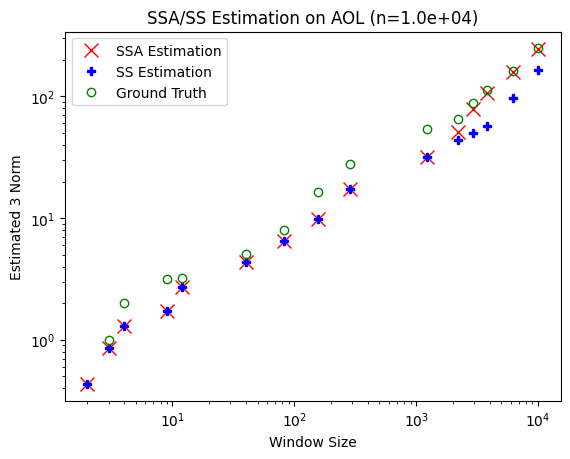

/var/folders/vm/qg92d4j56_l5x0q4g9hbq4j80000gn/T/ipykernel_23348/900554639.py:36: RuntimeWarning: divide by zero encountered in scalar divide
  ratio = lambda x, y: max(x, y)/min(x, y)


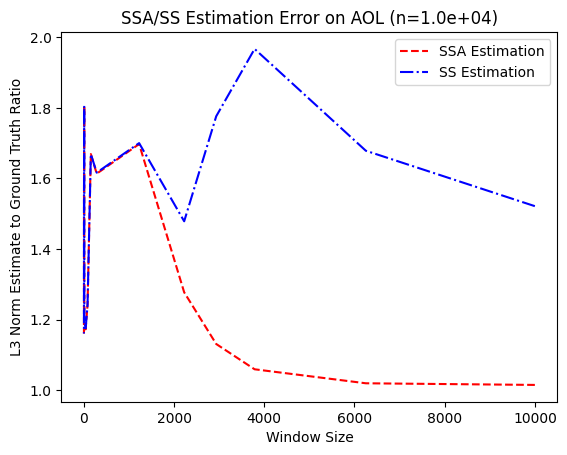

In [53]:
timesteps, est_ssa, est_ss, gt = calculate_estimates()
plot_estimates(timesteps, est_ssa, est_ss, gt)
plot_error_ratio(timesteps, est_ssa, est_ss, gt)

## AOL Dataset Test - Vary Selection Probability

In [ ]:
q_range = [
    1/10, 1/20, 1/40, 1/80, 1/160, 1/320, 1/640
]

est_ssa_2 = []
est_ss_2 = []
gt_2 = []

for q in q_range:
    hist_ssa = {} # maps timestep to ssa value
    hist_ss = {} # maps timestep to ss value
    hist_hh_sums = {} # maps timestep to hh sum value
    threads_vec_ssa = [] # stores thread identities
    num_threads_max = 20 # hyperparam for max counters
    vals = []
    r1 = 3
    r2 = 5
    order = 3
    filepath= "aol-processed.csv"
    m = int(2e5)
    W = int(m/2) # window size
    sel_idx = m - W
    q_ss = q
    selective_subsampling_augmented(heavy=hh, filepath=filepath, order=order, limit=m, r1=r1, r2=r2, q=q, q_ss=q_ss)
    timesteps, est_ssa, est_ss, _ = calculate_estimates()
    diffs = np.absolute(np.array(timesteps)-sel_idx)
    est_idx = diffs.argmin()
    est_ssa_2.append(est_ssa[est_idx])
    est_ss_2.append(est_ss[est_idx])
    _, temp_freq = np.unique(vals[:-W], return_counts=True)
    gt_2.append(np.linalg.norm(temp_freq, order))

### Visualize Results

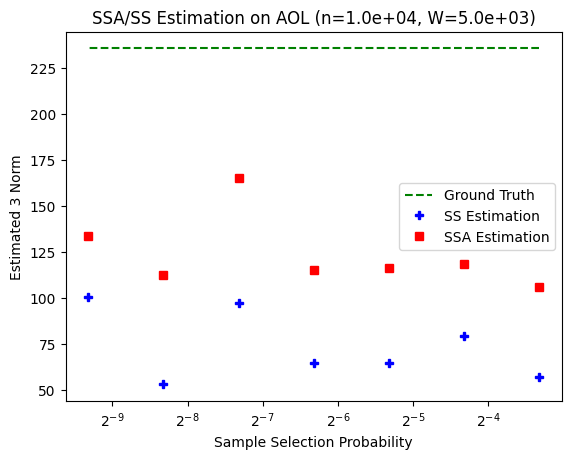

In [67]:
import matplotlib.pyplot as plt

_, ax = plt.subplots()

ax.plot(q_range, gt_2, 'g--', label='Ground Truth')
ax.plot(q_range, est_ss_2, 'bP', label='SS Estimation')
ax.plot(q_range, est_ssa_2, 'rs', label='SSA Estimation')
ax.set_xscale('log', base=2)
ax.set_title(f"SSA/SS Estimation on AOL (n={m:.1e}, W={W:.1e})")
ax.set_ylabel("Estimated 3 Norm")
ax.set_xlabel("Sample Selection Probability")
ax.legend()
plt.show()